# ResNet18-UNet side-tuning for KolektorSDD1 domain-shift crack segmentation.

Separate Colab notebook for adapting the small side branch on KolektorSDD1 while keeping the frozen SDD2-trained base model.

Side-tuning idea:
 frozen base segmentation model + small trainable side network
 final_logits = (1 - alpha) * base_logits + alpha * side_logits

For proper side-tuning, set BASE_CHECKPOINT_PATH to a trained source/base checkpoint. If it is left as None, the notebook still runs and mostly relies on the side branch, but this is closer to a lightweight side-network ablation.


In [1]:
# Colab CUDA setup
# Colab already provides a CUDA-enabled PyTorch build when the runtime is set to GPU.
!pip -q install segmentation-models-pytorch pillow tqdm scipy

from google.colab import drive
drive.mount('/content/drive')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.4 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
# 1. Imports
from contextlib import nullcontext
import json
import random
import shutil
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from scipy.ndimage import label
import torchvision.transforms.functional as TF
from torchvision.transforms import ElasticTransform, InterpolationMode
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau

import segmentation_models_pytorch as smp
from tqdm import tqdm


In [3]:
# 2. Config
PROJECT_ROOT = Path("/content")
DRIVE_DATA_ROOT = Path("/content/drive/MyDrive/KolektorSDD-boxes")
LOCAL_DATA_ROOT = Path("/content/KolektorSDD-boxes")
COPY_DATA_TO_LOCAL = True  # Faster than reading every image/mask from Google Drive each epoch.
DATA_ROOT = LOCAL_DATA_ROOT if COPY_DATA_TO_LOCAL else DRIVE_DATA_ROOT
IMG_HEIGHT = 1408
IMG_WIDTH = 512
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

USE_PREPROCESSED_TRAIN = True
PREPROCESS_CACHE_ROOT = Path("/content/ksdd1_aug_cache")
DRIVE_PREPROCESS_CACHE_ZIP = Path("/content/drive/MyDrive/ksdd1_aug_cache.zip")
COPY_PREPROCESS_CACHE_FROM_DRIVE = True
AUGMENTED_COPIES_PER_SAMPLE = 24
CACHE_COPIES_PER_EPOCH = 2
FORCE_REBUILD_PREPROCESS_CACHE = False

BATCH_SIZE = 4
NUM_EPOCHS = 50
LR = 1e-4
STRATEGY_EPOCHS = {
    "side_tuning": 50,
    "side_tuning_l4": 12,
}
STRATEGY_LR = {
    "side_tuning": 1e-4,
    "side_tuning_l4": 5e-5,
}

# Optional frozen source/base checkpoint.
# For a real customer-adaptation experiment, point this to a trained source model,
# e.g. "/content/drive/MyDrive/best_ksdd2_full_ft.pth".
BASE_CHECKPOINT_PATH = "/content/drive/MyDrive/best_ksdd2_full_ft.pth"
FREEZE_BASE_MODEL = True

# Side branch capacity and mixing.
SIDE_WIDTH = 32
SIDE_DROPOUT = 0.10
SIDE_INIT_MIX = 0.2
SIDE_LR_MULT = 1.0
MIX_LR_MULT = 5.0
BASE_LR_MULT = 0.1

ENCODER_LR_MULT = 0.2
FREEZE_ENCODER_BATCHNORM = True
VALIDATION_MIN_AREA = 1000
WEIGHT_DECAY = 1e-3
DECODER_DROPOUT = 0.2
GRAD_CLIP_NORM = 1.0
THR = 0.95
SEED = 42
REQUIRE_CUDA = True  # Keep True for the Colab GPU workflow.

POS_WEIGHT = 10.0
LOSS_MODE = "focal_dice"  # "bce_dice" or "focal_dice"
FOCAL_LOSS_WEIGHT = 0.4
DICE_LOSS_WEIGHT = 0.6
DICE_POSITIVE_ONLY = True  # focal handles negative images; Dice optimizes crack overlap
FOCAL_ALPHA = 0.75  # positive-class alpha; negatives use 1 - alpha
FOCAL_GAMMA = 2.0

SELECTION_METRIC = "composite"
IMAGE_FPR_PENALTY = 0.5
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 1e-4

USE_BALANCED_SAMPLER = True
POSITIVE_SAMPLE_WEIGHT = 6.0

ELASTIC_PROB = 0.3
ELASTIC_ALPHA = 25.0
ELASTIC_SIGMA = 5.0
GAUSSIAN_NOISE_PROB = 0.2
GAUSSIAN_NOISE_STD = 0.01

LR_SCHEDULER = "plateau"  # "plateau" adapts to the selected validation metric; "cosine" uses COSINE_T_MAX.
COSINE_T_MAX = 30
PLATEAU_FACTOR = 0.5
PLATEAU_PATIENCE = 2
PLATEAU_MIN_LR = 1e-6
THRESHOLD_PIXEL_FPR_LAMBDA = 1.0
THRESHOLD_MIN_AREAS = [0, 25, 50, 100, 200, 500, 1000, 1500, 2000]

FOREGROUND_PRIOR = None  # None estimates it from train masks; 0.01 is a common fixed fallback
PRIOR_CLAMP = (1e-4, 1.0 - 1e-4)
INIT_SEGMENTATION_BIAS = True

PAD_DIVISOR = 32
NUM_WORKERS = 2  # Colab DataLoader workers; set to 0 if you see multiprocessing issues.

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
MASK_EXTS = [".png", ".bmp", ".jpg", ".jpeg", ".tif", ".tiff"]


def mps_is_available():
    return hasattr(torch.backends, "mps") and torch.backends.mps.is_available()


def get_best_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if mps_is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = get_best_device()
DEVICE_TYPE = device.type
IS_CUDA = DEVICE_TYPE == "cuda"
IS_MPS = DEVICE_TYPE == "mps"
NON_BLOCKING_TRANSFER = IS_CUDA
USE_AMP = IS_CUDA
AMP_DTYPE = torch.float16
if REQUIRE_CUDA and not IS_CUDA:
    raise RuntimeError("CUDA is not available. In Colab, choose Runtime > Change runtime type > GPU.")

print(f"Using device: {device}")
if IS_CUDA:
    print(f"CUDA GPU: {torch.cuda.get_device_name(0)}")
    print(f"Mixed precision AMP: {'enabled' if USE_AMP else 'disabled'}")
elif IS_MPS:
    print("MPS fallback enabled. Set REQUIRE_CUDA=False if you intentionally want to run outside Colab CUDA.")
else:
    print("CUDA is not available. In Colab, choose Runtime > Change runtime type > GPU.")


def move_to_device(tensor):
    return tensor.to(device, non_blocking=NON_BLOCKING_TRANSFER)


def load_weights(checkpoint_path):
    return torch.load(checkpoint_path, map_location=device, weights_only=True)


def amp_autocast():
    if not USE_AMP:
        return nullcontext()
    if hasattr(torch, "amp") and hasattr(torch.amp, "autocast"):
        return torch.amp.autocast("cuda", dtype=AMP_DTYPE, enabled=USE_AMP)
    return torch.cuda.amp.autocast(dtype=AMP_DTYPE, enabled=USE_AMP)


def make_grad_scaler():
    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
        try:
            return torch.amp.GradScaler("cuda", enabled=USE_AMP)
        except TypeError:
            return torch.cuda.amp.GradScaler(enabled=USE_AMP)
    return torch.cuda.amp.GradScaler(enabled=USE_AMP)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if mps_is_available() and hasattr(torch, "mps") and hasattr(torch.mps, "manual_seed"):
        torch.mps.manual_seed(seed)


set_seed(SEED)


Using device: cuda
CUDA GPU: Tesla T4
Mixed precision AMP: enabled


In [4]:
# 3. Dataset collection and batching
# SDD1 stores each object in a kosXX folder:
#   Part0.jpg       -> greyscale image strip
#   Part0_label.bmp -> ground-truth mask

SDD1_VAL_FRACTION = 0.20


def _has_train_test(root):
    return (root / "train").is_dir() and (root / "test").is_dir()


def _has_sdd1_groups(root):
    for child in root.iterdir() if root.exists() else []:
        if not child.is_dir():
            continue
        has_image = any(path.suffix.lower() in IMAGE_EXTS and not is_gt_file(path) for path in child.iterdir() if path.is_file())
        has_label = any(path.stem.lower().endswith("_label") for path in child.iterdir() if path.is_file())
        if has_image and has_label:
            return True
    return False


def resolve_data_root(data_root):
    root = Path(data_root)
    if not root.exists():
        raise FileNotFoundError(
            f"DATA_ROOT does not exist: {data_root}\n"
            "Mount Google Drive and set DATA_ROOT to KolektorSDD-boxes or a train/test dataset folder."
        )

    candidates = [root, root / "KolektorSDD-boxes", root / "KolektorSDD", root / "KolektorSDD2"]
    for candidate in candidates:
        if candidate.exists() and (_has_train_test(candidate) or _has_sdd1_groups(candidate)):
            return candidate

    for child in root.rglob("*"):
        if child.is_dir() and (_has_train_test(child) or _has_sdd1_groups(child)):
            return child

    raise FileNotFoundError(
        f"Could not find SDD1 kosXX folders or SDD2 train/test folders under: {root}"
    )


def is_gt_file(path):
    lower = path.stem.lower()
    return lower.endswith("_gt") or lower.endswith("_label") or lower.endswith("_mask")


def find_ksdd2_mask(img_path):
    stems = [
        f"{img_path.stem}_GT",
        f"{img_path.stem}_gt",
        f"{img_path.stem}_label",
        f"{img_path.stem}_mask",
    ]
    mask_exts = list(dict.fromkeys([img_path.suffix.lower()] + MASK_EXTS))
    for stem in stems:
        for ext in mask_exts:
            mask_path = img_path.with_name(f"{stem}{ext}")
            if mask_path.exists():
                return mask_path
    return None


def mask_has_positive(mask_path):
    if mask_path is None:
        return False
    mask = np.array(Image.open(mask_path).convert("L"))
    return bool((mask > 0).any())


def estimate_foreground_prior(samples):
    positive_pixels = 0
    total_pixels = 0

    for sample in tqdm(samples, desc="Estimating foreground prior", leave=False):
        if sample["mask"] is None:
            with Image.open(sample["image"]) as img:
                width, height = img.size
            total_pixels += width * height
            continue

        mask = np.array(Image.open(sample["mask"]).convert("L"))
        positive_pixels += int((mask > 0).sum())
        total_pixels += int(mask.size)

    prior = positive_pixels / max(total_pixels, 1)
    return float(np.clip(prior, *PRIOR_CLAMP))


def collect_split_samples(root, split_name):
    split_dir = root / split_name
    if not split_dir.is_dir():
        raise FileNotFoundError(f"Missing split folder: {split_dir}")

    samples = []
    for img_path in sorted(split_dir.rglob("*")):
        if not img_path.is_file():
            continue
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue
        if is_gt_file(img_path):
            continue

        mask_path = find_ksdd2_mask(img_path)
        samples.append({
            "image": str(img_path),
            "mask": str(mask_path) if mask_path is not None else None,
            "split": split_name,
            "has_crack": mask_has_positive(mask_path),
        })

    if not samples:
        raise RuntimeError(f"No input images found in {split_dir}")
    return samples


def collect_sdd1_samples(root):
    samples = []
    for kos_folder in sorted(path for path in root.iterdir() if path.is_dir()):
        for img_path in sorted(kos_folder.glob("*.jpg")):
            if not img_path.is_file() or is_gt_file(img_path):
                continue
            mask_path = img_path.with_name(f"{img_path.stem}_label.bmp")
            if not mask_path.exists():
                mask_path = find_ksdd2_mask(img_path)
            samples.append({
                "image": str(img_path),
                "mask": str(mask_path) if mask_path is not None else None,
                "split": None,
                "group": kos_folder.name,
                "has_crack": mask_has_positive(mask_path),
            })
    if not samples:
        raise RuntimeError(f"No SDD1 kosXX/Part*.jpg samples found in {root}")
    return samples


def split_sdd1_samples(root, val_fraction=SDD1_VAL_FRACTION):
    samples = collect_sdd1_samples(root)
    positive = [sample for sample in samples if sample["has_crack"]]
    negative = [sample for sample in samples if not sample["has_crack"]]
    rng = random.Random(SEED)
    rng.shuffle(positive)
    rng.shuffle(negative)

    def split_class(items):
        if not items:
            return [], []
        n_val = max(1, int(round(len(items) * val_fraction)))
        n_val = min(n_val, max(1, len(items) - 1)) if len(items) > 1 else 1
        return items[n_val:], items[:n_val]

    pos_train, pos_val = split_class(positive)
    neg_train, neg_val = split_class(negative)
    if pos_train:
        neg_train = rng.sample(neg_train, min(len(neg_train), 2 * len(pos_train)))

    train_samples = pos_train + neg_train
    val_samples = pos_val + neg_val
    rng.shuffle(train_samples)
    rng.shuffle(val_samples)

    for sample in train_samples:
        sample["split"] = "train"
    for sample in val_samples:
        sample["split"] = "test"
    return train_samples, val_samples

def elastic_transform_pair(img, mask):
    width, height = img.size
    displacement = ElasticTransform.get_params(
        alpha=[ELASTIC_ALPHA, ELASTIC_ALPHA],
        sigma=[ELASTIC_SIGMA, ELASTIC_SIGMA],
        size=[height, width],
    )
    img = TF.elastic_transform(
        img,
        displacement,
        interpolation=InterpolationMode.BILINEAR,
        fill=[0, 0, 0],
    )
    mask = TF.elastic_transform(
        mask,
        displacement,
        interpolation=InterpolationMode.NEAREST,
        fill=[0],
    )
    return img, mask


def load_sample_pil(sample):
    img_path = sample["image"]
    mask_path = sample["mask"]

    img = Image.open(img_path).convert("RGB")
    if mask_path is None:
        mask = Image.new("L", img.size, 0)
    else:
        mask = Image.open(mask_path).convert("L")
        if mask.size != img.size:
            raise ValueError(
                f"Image/mask size mismatch:\n"
                f"image={img_path}, size={img.size}\n"
                f"mask={mask_path}, size={mask.size}"
            )

    img = TF.resize(img, IMG_SIZE, interpolation=InterpolationMode.BILINEAR)
    mask = TF.resize(mask, IMG_SIZE, interpolation=InterpolationMode.NEAREST)
    return img, mask


def apply_training_augmentation(img, mask):
    if random.random() < 0.5:
        img = TF.hflip(img)
        mask = TF.hflip(mask)
    if random.random() < 0.5:
        img = TF.vflip(img)
        mask = TF.vflip(mask)
    if random.random() < 0.3:
        img = TF.rotate(img, angle=180)
        mask = TF.rotate(mask, angle=180)

    if random.random() < ELASTIC_PROB:
        img, mask = elastic_transform_pair(img, mask)

    if random.random() < 0.4:
        img = TF.adjust_brightness(img, brightness_factor=random.uniform(0.9, 1.1))
        img = TF.adjust_contrast(img, contrast_factor=random.uniform(0.9, 1.1))

    return img, mask


def maybe_add_gaussian_noise(img_t):
    if random.random() < GAUSSIAN_NOISE_PROB:
        img_t = (img_t + torch.randn_like(img_t) * GAUSSIAN_NOISE_STD).clamp(0.0, 1.0)
    return img_t


def normalize_image_tensor(img_t):
    return TF.normalize(
        img_t,
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    )


class CrackSegDataset(Dataset):
    def __init__(self, samples, augment=True):
        self.samples = samples
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img, mask = load_sample_pil(sample)

        if self.augment:
            img, mask = apply_training_augmentation(img, mask)

        img = TF.to_tensor(img)
        if self.augment:
            img = maybe_add_gaussian_noise(img)
        img = normalize_image_tensor(img)

        mask_np = np.array(mask)
        mask_t = torch.from_numpy((mask_np > 0).astype(np.float32))[None]
        return img, mask_t


def _ceil_to_multiple(x, divisor):
    if divisor is None or divisor <= 1:
        return x
    return int(np.ceil(x / divisor) * divisor)


def pad_collate(batch):
    imgs, masks = zip(*batch)

    max_h = _ceil_to_multiple(max(img.shape[-2] for img in imgs), PAD_DIVISOR)
    max_w = _ceil_to_multiple(max(img.shape[-1] for img in imgs), PAD_DIVISOR)

    padded_imgs, padded_masks, valid_masks = [], [], []
    for img, mask in zip(imgs, masks):
        h, w = img.shape[-2:]
        pad_h = max_h - h
        pad_w = max_w - w

        padded_imgs.append(F.pad(img, (0, pad_w, 0, pad_h), value=0.0))
        padded_masks.append(F.pad(mask, (0, pad_w, 0, pad_h), value=0.0))

        valid = torch.zeros((1, max_h, max_w), dtype=torch.float32)
        valid[:, :h, :w] = 1.0
        valid_masks.append(valid)

    return torch.stack(padded_imgs), torch.stack(padded_masks), torch.stack(valid_masks)


In [5]:
# 4. Data preparation, official split, and preprocessing cache
def _split_counts(samples):
    positives = sum(s["has_crack"] for s in samples)
    negatives = len(samples) - positives
    return positives, negatives


def prepare_data_root():
    if not COPY_DATA_TO_LOCAL:
        return resolve_data_root(DRIVE_DATA_ROOT)

    try:
        local_root = resolve_data_root(LOCAL_DATA_ROOT)
        print(f"Using local dataset cache: {local_root}")
        return local_root
    except FileNotFoundError:
        pass

    source_root = resolve_data_root(DRIVE_DATA_ROOT)
    print(f"Copying dataset to Colab local disk: {source_root} -> {LOCAL_DATA_ROOT}")
    shutil.copytree(source_root, LOCAL_DATA_ROOT, dirs_exist_ok=True)
    return resolve_data_root(LOCAL_DATA_ROOT)


def load_official_split(data_root):
    root = resolve_data_root(data_root)
    if _has_train_test(root):
        train_samples = collect_split_samples(root, "train")
        val_samples = collect_split_samples(root, "test")
        split_name = "official train/test"
    else:
        train_samples, val_samples = split_sdd1_samples(root)
        split_name = "old KolektorSDD stratified sample split"

    train_pos, train_neg = _split_counts(train_samples)
    val_pos, val_neg = _split_counts(val_samples)

    print(f"Dataset root: {root}")
    print(f"Split: {split_name}")
    print(f"Train: {len(train_samples)} images ({train_pos} positive, {train_neg} negative)")
    print(f"Test/val: {len(val_samples)} images ({val_pos} positive, {val_neg} negative)")

    return train_samples, val_samples


def preprocess_cache_config(num_raw_samples):
    return {
        "num_raw_samples": int(num_raw_samples),
        "copies_per_sample": int(AUGMENTED_COPIES_PER_SAMPLE),
        "seed": int(SEED),
        "image_size": list(IMG_SIZE),
        "elastic_prob": float(ELASTIC_PROB),
        "elastic_alpha": float(ELASTIC_ALPHA),
        "elastic_sigma": float(ELASTIC_SIGMA),
        "gaussian_noise_prob": float(GAUSSIAN_NOISE_PROB),
        "gaussian_noise_std": float(GAUSSIAN_NOISE_STD),
    }


def load_preprocess_manifest(cache_root, expected_config):
    manifest_path = Path(cache_root) / "manifest.json"
    if not manifest_path.exists():
        return None

    manifest = json.loads(manifest_path.read_text())
    if manifest.get("config") != expected_config:
        return None

    samples = manifest.get("samples", [])
    for sample in samples:
        if not Path(sample["image"]).is_file():
            return None
        if sample.get("mask") is not None and not Path(sample["mask"]).is_file():
            return None
    return samples


def restore_preprocess_cache_from_drive(cache_root, expected_config):
    if not COPY_PREPROCESS_CACHE_FROM_DRIVE:
        return None

    drive_zip = Path(DRIVE_PREPROCESS_CACHE_ZIP)
    if not drive_zip.exists():
        print(f"Drive cache zip not found: {drive_zip}")
        return None

    cache_root = Path(cache_root)
    local_zip = PROJECT_ROOT / drive_zip.name
    print(f"Copying preprocessed cache zip from Drive: {drive_zip} -> {local_zip}")
    shutil.copy2(drive_zip, local_zip)

    if cache_root.exists():
        shutil.rmtree(cache_root)

    print(f"Unzipping preprocessed cache into {PROJECT_ROOT}")
    shutil.unpack_archive(str(local_zip), str(PROJECT_ROOT))

    cached_samples = load_preprocess_manifest(cache_root, expected_config)
    if cached_samples is None:
        print("Restored cache did not match the current notebook config; falling back to cache build.")
        if cache_root.exists():
            shutil.rmtree(cache_root)
        return None

    print(f"Restored preprocessed training cache: {cache_root} ({len(cached_samples)} samples)")
    return cached_samples


def save_cached_augmented_sample(sample, out_dir, sample_idx, copy_idx):
    img, mask = load_sample_pil(sample)
    img, mask = apply_training_augmentation(img, mask)

    img_t = maybe_add_gaussian_noise(TF.to_tensor(img))
    img_np = (img_t.permute(1, 2, 0).numpy() * 255.0).round().clip(0, 255).astype(np.uint8)
    mask_np = (np.array(mask) > 0).astype(np.uint8) * 255

    stem = f"{sample_idx:05d}_aug{copy_idx:02d}"
    image_path = out_dir / f"{stem}.png"
    mask_path = out_dir / f"{stem}_GT.png"

    Image.fromarray(img_np).save(image_path, compress_level=1)
    Image.fromarray(mask_np).save(mask_path, compress_level=1)

    return {
        "image": str(image_path),
        "mask": str(mask_path),
        "split": "train_preprocessed",
        "has_crack": bool(sample["has_crack"]),
        "source_image": sample["image"],
        "copy_idx": int(copy_idx),
    }


def build_preprocessed_train_cache(train_samples):
    cache_root = Path(PREPROCESS_CACHE_ROOT)
    cache_config = preprocess_cache_config(len(train_samples))

    if FORCE_REBUILD_PREPROCESS_CACHE and cache_root.exists():
        shutil.rmtree(cache_root)

    cached_samples = load_preprocess_manifest(cache_root, cache_config)
    if cached_samples is not None:
        print(f"Using preprocessed training cache: {cache_root} ({len(cached_samples)} samples)")
        return cached_samples

    cached_samples = restore_preprocess_cache_from_drive(cache_root, cache_config)
    if cached_samples is not None:
        return cached_samples

    out_dir = cache_root / "train"
    if cache_root.exists():
        shutil.rmtree(cache_root)
    out_dir.mkdir(parents=True, exist_ok=True)

    print(
        f"Preprocessing training augmentations to {cache_root} "
        f"({AUGMENTED_COPIES_PER_SAMPLE} copy/copies per sample)"
    )
    start = time.time()
    py_rng_state = random.getstate()
    torch_rng_state = torch.random.get_rng_state()
    random.seed(SEED)
    torch.manual_seed(SEED)

    cached_samples = []
    try:
        for sample_idx, sample in enumerate(tqdm(train_samples, desc="Preprocessing train cache")):
            for copy_idx in range(AUGMENTED_COPIES_PER_SAMPLE):
                cached_samples.append(save_cached_augmented_sample(sample, out_dir, sample_idx, copy_idx))
    finally:
        random.setstate(py_rng_state)
        torch.random.set_rng_state(torch_rng_state)

    elapsed = time.time() - start
    manifest = {
        "config": cache_config,
        "samples": cached_samples,
        "elapsed_seconds": elapsed,
        "cache_pool": {
            "copies_per_epoch": int(CACHE_COPIES_PER_EPOCH),
            "description": "Runtime sampling hint only.",
        },
    }
    (cache_root / "manifest.json").write_text(json.dumps(manifest, indent=2))
    print(f"Preprocessing complete in {elapsed / 60:.1f} min | Cached samples: {len(cached_samples)}")
    return cached_samples


def prepare_training_samples(train_samples):
    if not USE_PREPROCESSED_TRAIN:
        print("Using online augmentation during training.")
        return train_samples, True

    cached_samples = build_preprocessed_train_cache(train_samples)
    return cached_samples, False


def make_epoch_subset(cached_samples, copies_per_epoch, seed):
    by_source = {}
    for sample in cached_samples:
        source_key = sample.get("source_image", sample.get("image"))
        by_source.setdefault(source_key, []).append(sample)

    rng = random.Random(seed)
    subset = []
    for source_samples in by_source.values():
        k = min(int(copies_per_epoch), len(source_samples))
        subset.extend(rng.sample(source_samples, k))
    rng.shuffle(subset)
    return subset


In [6]:
# 5. Model - frozen base ResNet18-UNet + trainable side network
def initialize_segmentation_bias(model, prior_prob):
    prior_prob = float(np.clip(prior_prob, *PRIOR_CLAMP))
    bias_value = float(np.log(prior_prob / (1.0 - prior_prob)))

    for module in reversed(list(model.segmentation_head.modules())):
        if isinstance(module, nn.Conv2d) and module.out_channels == 1:
            if module.bias is not None:
                nn.init.constant_(module.bias, bias_value)
                print(f"Initialized base segmentation bias with prior={prior_prob:.6f}, bias={bias_value:.4f}")
            return model

    print("Warning: no 1-channel Conv2d found in segmentation_head for bias initialization.")
    return model


def initialize_conv_bias(conv, prior_prob):
    prior_prob = float(np.clip(prior_prob, *PRIOR_CLAMP))
    bias_value = float(np.log(prior_prob / (1.0 - prior_prob)))
    if conv.bias is not None:
        nn.init.constant_(conv.bias, bias_value)


def logit_from_probability(prob):
    prob = float(np.clip(prob, 1e-4, 1.0 - 1e-4))
    return float(np.log(prob / (1.0 - prob)))


def make_group_norm(channels, max_groups=8):
    groups = min(max_groups, channels)
    while channels % groups != 0:
        groups -= 1
    return nn.GroupNorm(groups, channels)


class ConvGNAct(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            make_group_norm(out_channels),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout) if dropout and dropout > 0 else nn.Identity(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            make_group_norm(out_channels),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class TinySideUNet(nn.Module):
    """Small trainable side branch for segmentation-logit corrections."""

    def __init__(self, in_channels=3, width=SIDE_WIDTH, dropout=SIDE_DROPOUT, foreground_prior=None):
        super().__init__()
        w = int(width)
        self.enc1 = ConvGNAct(in_channels, w, dropout=dropout)
        self.enc2 = ConvGNAct(w, w * 2, dropout=dropout)
        self.enc3 = ConvGNAct(w * 2, w * 4, dropout=dropout)
        self.bottleneck = ConvGNAct(w * 4, w * 8, dropout=dropout)
        self.dec3 = ConvGNAct(w * 8 + w * 4, w * 4, dropout=dropout)
        self.dec2 = ConvGNAct(w * 4 + w * 2, w * 2, dropout=dropout)
        self.dec1 = ConvGNAct(w * 2 + w, w, dropout=dropout)
        self.head = nn.Conv2d(w, 1, kernel_size=1)
        if INIT_SEGMENTATION_BIAS and foreground_prior is not None:
            initialize_conv_bias(self.head, foreground_prior)

    def forward(self, x):
        input_shape = x.shape[-2:]
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, kernel_size=2))
        e3 = self.enc3(F.max_pool2d(e2, kernel_size=2))
        b = self.bottleneck(F.max_pool2d(e3, kernel_size=2))

        d3 = F.interpolate(b, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = F.interpolate(d3, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = F.interpolate(d2, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        logits = self.head(d1)
        if logits.shape[-2:] != input_shape:
            logits = F.interpolate(logits, size=input_shape, mode="bilinear", align_corners=False)
        return logits


def build_base_unet(foreground_prior=None):
    model = smp.Unet(
        encoder_name="resnet18",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        decoder_dropout=DECODER_DROPOUT,
        activation=None,
    )
    if INIT_SEGMENTATION_BIAS and foreground_prior is not None:
        model = initialize_segmentation_bias(model, foreground_prior)
    return model


def maybe_load_base_checkpoint(base_model):
    if BASE_CHECKPOINT_PATH is None:
        print(
            "BASE_CHECKPOINT_PATH is None. The frozen base branch is ImageNet-initialized "
            "with an untrained decoder; SIDE_INIT_MIX should stay close to 1.0 for this ablation."
        )
        return base_model, False

    checkpoint_path = Path(BASE_CHECKPOINT_PATH)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"BASE_CHECKPOINT_PATH does not exist: {checkpoint_path}")

    state = load_weights(checkpoint_path)
    missing, unexpected = base_model.load_state_dict(state, strict=False)
    print(f"Loaded frozen base checkpoint: {checkpoint_path}")
    if missing:
        print(f"Base checkpoint missing keys: {len(missing)}")
    if unexpected:
        print(f"Base checkpoint unexpected keys: {len(unexpected)}")
    return base_model, True


class SideTuningSegmentationModel(nn.Module):
    def __init__(
        self,
        base_model,
        side_model,
        side_init_mix=SIDE_INIT_MIX,
        freeze_base=FREEZE_BASE_MODEL,
    ):
        super().__init__()
        self.base_model = base_model
        self.side_model = side_model
        self.mix_logit = nn.Parameter(torch.tensor(logit_from_probability(side_init_mix), dtype=torch.float32))
        self.freeze_base = bool(freeze_base)
        self.set_base_trainable(not self.freeze_base)

    def set_base_trainable(self, trainable):
        self.freeze_base = not bool(trainable)
        for p in self.base_model.parameters():
            p.requires_grad = bool(trainable)
        if self.freeze_base:
            self.base_model.eval()
        return self

    def side_mix(self):
        return torch.sigmoid(self.mix_logit)

    def forward(self, x):
        if self.freeze_base:
            self.base_model.eval()
            with torch.no_grad():
                base_logits = self.base_model(x)
        else:
            base_logits = self.base_model(x)
        side_logits = self.side_model(x)
        mix = self.side_mix().to(dtype=side_logits.dtype)
        return (1.0 - mix) * base_logits.to(dtype=side_logits.dtype) + mix * side_logits


def build_model(foreground_prior=None, load_base_checkpoint=True):
    base_model = build_base_unet(foreground_prior)
    loaded_base = False
    if load_base_checkpoint:
        base_model, loaded_base = maybe_load_base_checkpoint(base_model)
    side_model = TinySideUNet(foreground_prior=foreground_prior)

    side_init_mix = SIDE_INIT_MIX
    if load_base_checkpoint and not loaded_base and side_init_mix < 0.95:
        print("No trained base checkpoint was loaded; overriding side mix to 0.99.")
        side_init_mix = 0.99

    model = SideTuningSegmentationModel(
        base_model=base_model,
        side_model=side_model,
        side_init_mix=side_init_mix,
        freeze_base=FREEZE_BASE_MODEL,
    )
    print(f"Initial side-branch mix alpha={model.side_mix().item():.4f}")
    return model.to(device)


In [7]:
# 5b. Side-tuning adaptation strategy
def set_encoder_norm_eval(model):
    if not FREEZE_ENCODER_BATCHNORM:
        return model
    if hasattr(model, "base_model") and getattr(model, "freeze_base", False):
        model.base_model.eval()
    if hasattr(model, "base_model"):
        for module in model.base_model.encoder.modules():
            if isinstance(module, (nn.BatchNorm2d, nn.SyncBatchNorm)):
                module.eval()
    return model


def freeze_encoder_norm_parameters(model):
    if not FREEZE_ENCODER_BATCHNORM:
        return model
    if hasattr(model, "base_model"):
        for module in model.base_model.encoder.modules():
            if isinstance(module, (nn.BatchNorm2d, nn.SyncBatchNorm)):
                module.eval()
                for p in module.parameters():
                    p.requires_grad = False
    return model


def apply_strategy(model, strategy_name="side_tuning"):
    for p in model.parameters():
        p.requires_grad = False

    if strategy_name == "side_tuning":
        model.set_base_trainable(False)
        for p in model.side_model.parameters():
            p.requires_grad = True
        model.mix_logit.requires_grad = True

    elif strategy_name == "side_tuning_l4":
        # Mostly side-tuning, but also lets the deepest frozen base features move a little.
        model.set_base_trainable(False)
        for p in model.side_model.parameters():
            p.requires_grad = True
        model.mix_logit.requires_grad = True
        for p in model.base_model.encoder.layer4.parameters():
            p.requires_grad = True
        for p in model.base_model.decoder.parameters():
            p.requires_grad = True
        for p in model.base_model.segmentation_head.parameters():
            p.requires_grad = True
        model.freeze_base = False

    else:
        raise ValueError(f"Unknown side-tuning strategy: {strategy_name}")

    freeze_encoder_norm_parameters(model)
    return model


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def count_side_params(model):
    return sum(p.numel() for p in model.side_model.parameters())


def count_base_params(model):
    return sum(p.numel() for p in model.base_model.parameters())


In [8]:
# 6. Loss with valid-pixel masking for padded batches
def dice_loss(logits, targets, valid=None, eps=1e-6):
    if valid is None:
        valid = torch.ones_like(targets)

    probs = torch.sigmoid(logits) * valid
    targets = targets * valid

    if DICE_POSITIVE_ONLY:
        positive_samples = targets.sum(dim=(1, 2, 3)) > 0
        if not positive_samples.any():
            return logits.sum() * 0.0
        probs = probs[positive_samples]
        targets = targets[positive_samples]

    inter = (probs * targets).sum(dim=(2, 3))
    denom = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    return 1 - ((2 * inter + eps) / (denom + eps)).mean()


def bce_loss_masked(logits, targets, valid=None):
    if valid is None:
        valid = torch.ones_like(targets)

    pos_weight = torch.tensor([POS_WEIGHT], device=logits.device)
    bce = nn.functional.binary_cross_entropy_with_logits(
        logits, targets, pos_weight=pos_weight, reduction="none"
    )
    return (bce * valid).sum() / valid.sum().clamp_min(1.0)


def focal_loss(logits, targets, valid=None, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA):
    if valid is None:
        valid = torch.ones_like(targets)

    bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    probs = torch.sigmoid(logits)
    pt = probs * targets + (1 - probs) * (1 - targets)
    alpha_t = alpha * targets + (1 - alpha) * (1 - targets)
    focal = alpha_t * (1 - pt).pow(gamma) * bce * valid
    return focal.sum() / valid.sum().clamp_min(1.0)


def segmentation_loss(logits, targets, valid=None):
    dice = dice_loss(logits, targets, valid)

    if LOSS_MODE == "bce_dice":
        bce = bce_loss_masked(logits, targets, valid)
        return FOCAL_LOSS_WEIGHT * bce + DICE_LOSS_WEIGHT * dice
    if LOSS_MODE == "focal_dice":
        focal = focal_loss(logits, targets, valid)
        return FOCAL_LOSS_WEIGHT * focal + DICE_LOSS_WEIGHT * dice

    raise ValueError(f"Unknown LOSS_MODE: {LOSS_MODE}")


In [9]:
# 7. Segmentation metrics
METRIC_NAMES = ["dice", "dice_positive", "iou", "precision", "recall", "fpr", "image_fpr", "composite"]


def remove_small_components_np(mask, min_area=0):
    """Remove connected predicted blobs smaller than min_area pixels."""
    mask = mask.astype(bool, copy=False)
    if min_area is None or min_area <= 0:
        return mask

    structure = np.ones((3, 3), dtype=np.uint8)
    labeled, num_features = label(mask, structure=structure)
    if num_features == 0:
        return mask

    component_sizes = np.bincount(labeled.ravel())
    keep_component = component_sizes >= min_area
    keep_component[0] = False
    return keep_component[labeled]


def remove_small_components_batch(pred_bool, valid_bool=None, min_area=0):
    if min_area is None or min_area <= 0:
        return pred_bool

    pred_cpu = pred_bool.detach().cpu().numpy().astype(bool)
    if valid_bool is not None:
        valid_cpu = valid_bool.detach().cpu().numpy().astype(bool)
    else:
        valid_cpu = np.ones_like(pred_cpu, dtype=bool)

    cleaned = np.zeros_like(pred_cpu, dtype=bool)
    for idx in range(pred_cpu.shape[0]):
        mask_2d = pred_cpu[idx, 0] & valid_cpu[idx, 0]
        cleaned[idx, 0] = remove_small_components_np(mask_2d, min_area=min_area)

    return torch.as_tensor(cleaned, device=pred_bool.device, dtype=torch.bool)


def confusion_counts(logits, targets, valid=None, thr=None, min_area=0):
    if thr is None:
        thr = THR
    if valid is None:
        valid = torch.ones_like(targets)

    valid_bool = valid > 0.5
    pred_bool = (torch.sigmoid(logits) > thr) & valid_bool
    pred_bool = remove_small_components_batch(pred_bool, valid_bool=valid_bool, min_area=min_area)
    target_bool = (targets > 0.5) & valid_bool

    per_tp = (pred_bool & target_bool).flatten(1).sum(dim=1).float()
    per_fp = (pred_bool & ~target_bool & valid_bool).flatten(1).sum(dim=1).float()
    per_fn = (~pred_bool & target_bool & valid_bool).flatten(1).sum(dim=1).float()

    tp = per_tp.sum().item()
    fp = per_fp.sum().item()
    fn = per_fn.sum().item()
    tn = (~pred_bool & ~target_bool & valid_bool).sum().item()

    gt_positive = target_bool.flatten(1).any(dim=1)
    pred_positive = pred_bool.flatten(1).any(dim=1)
    image_negatives = (~gt_positive).sum().item()
    image_fp = ((~gt_positive) & pred_positive).sum().item()

    dice_positive_sum = 0.0
    dice_positive_count = gt_positive.sum().item()
    if dice_positive_count > 0:
        positive_dice = (2 * per_tp[gt_positive] + 1e-6) / (
            2 * per_tp[gt_positive] + per_fp[gt_positive] + per_fn[gt_positive] + 1e-6
        )
        dice_positive_sum = positive_dice.sum().item()

    counts = {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "dice_positive_sum": dice_positive_sum,
        "dice_positive_count": dice_positive_count,
        "image_fp": image_fp,
        "image_negatives": image_negatives,
    }
    return counts


def add_counts(total, batch_counts):
    for key in total:
        total[key] += batch_counts[key]


def selection_score(dice_positive, image_fpr, pixel_fpr):
    return (
        dice_positive
        - IMAGE_FPR_PENALTY * image_fpr
        - THRESHOLD_PIXEL_FPR_LAMBDA * pixel_fpr
    )


def metrics_from_counts(counts, eps=1e-6):
    tp = counts["tp"]
    fp = counts["fp"]
    fn = counts["fn"]
    tn = counts["tn"]

    dice_denom = 2 * tp + fp + fn
    iou_denom = tp + fp + fn
    precision_denom = tp + fp
    recall_denom = tp + fn
    fpr_denom = fp + tn
    dice_positive_count = counts["dice_positive_count"]
    image_fpr_denom = counts["image_negatives"]

    metrics = {
        "dice": (2 * tp + eps) / (dice_denom + eps) if dice_denom > 0 else 1.0,
        "dice_positive": counts["dice_positive_sum"] / (dice_positive_count + eps) if dice_positive_count > 0 else 0.0,
        "iou": (tp + eps) / (iou_denom + eps) if iou_denom > 0 else 1.0,
        "precision": tp / (precision_denom + eps),
        "recall": tp / (recall_denom + eps),
        "fpr": fp / (fpr_denom + eps) if fpr_denom > 0 else 0.0,
        "image_fpr": counts["image_fp"] / (image_fpr_denom + eps) if image_fpr_denom > 0 else 0.0,
    }
    metrics["composite"] = selection_score(
        metrics["dice_positive"],
        metrics["image_fpr"],
        metrics["fpr"],
    )
    return metrics


In [10]:
# 8. Train / validation loop
def sync_accelerator():
    if IS_CUDA:
        torch.cuda.synchronize()


def run_epoch(model, loader, optimizer=None, scaler=None, train=True, thr=None, min_area=0):
    if train:
        model.train()
        set_encoder_norm_eval(model)
    else:
        model.eval()

    wall_start = time.perf_counter()
    model_seconds = 0.0
    metric_seconds = 0.0
    transfer_seconds = 0.0
    total_loss = 0.0
    total_samples = 0
    counts = {
        "tp": 0,
        "fp": 0,
        "fn": 0,
        "tn": 0,
        "dice_positive_sum": 0.0,
        "dice_positive_count": 0,
        "image_fp": 0,
        "image_negatives": 0,
    }

    for x, y, valid in tqdm(loader, leave=False):
        transfer_start = time.perf_counter()
        x = move_to_device(x)
        y = move_to_device(y)
        valid = move_to_device(valid)
        sync_accelerator()
        transfer_seconds += time.perf_counter() - transfer_start

        if train:
            optimizer.zero_grad(set_to_none=True)

        grad_context = nullcontext() if train else torch.no_grad()
        model_start = time.perf_counter()
        with grad_context:
            with amp_autocast():
                logits = model(x)
                loss = segmentation_loss(logits, y, valid)

            if train:
                if scaler is None:
                    loss.backward()
                    if GRAD_CLIP_NORM is not None and GRAD_CLIP_NORM > 0:
                        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
                    optimizer.step()
                else:
                    scaler.scale(loss).backward()
                    if GRAD_CLIP_NORM is not None and GRAD_CLIP_NORM > 0:
                        scaler.unscale_(optimizer)
                        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
                    scaler.step(optimizer)
                    scaler.update()
        sync_accelerator()
        model_seconds += time.perf_counter() - model_start

        batch_size = x.size(0)
        logits_for_metrics = logits.detach()
        total_loss += loss.detach().item() * batch_size
        total_samples += batch_size

        metric_start = time.perf_counter()
        batch_counts = confusion_counts(logits_for_metrics, y.detach(), valid.detach(), thr=thr, min_area=min_area)
        sync_accelerator()
        metric_seconds += time.perf_counter() - metric_start
        add_counts(counts, batch_counts)

    wall_seconds = time.perf_counter() - wall_start
    metrics = metrics_from_counts(counts)
    metrics["loss"] = total_loss / max(total_samples, 1)
    metrics["wall_seconds"] = wall_seconds
    metrics["model_seconds"] = model_seconds
    metrics["metric_seconds"] = metric_seconds
    metrics["transfer_seconds"] = transfer_seconds
    metrics["other_seconds"] = max(wall_seconds - model_seconds - metric_seconds - transfer_seconds, 0.0)
    metrics["samples_per_second"] = total_samples / max(model_seconds, 1e-9)
    metrics["wall_samples_per_second"] = total_samples / max(wall_seconds, 1e-9)
    return metrics


In [11]:
# 9. Training
TRACKED_HISTORY = ["loss"] + METRIC_NAMES


def make_optimizer(model, lr=LR):
    side_params = []
    mix_params = []
    base_params = []
    other_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name == "mix_logit":
            mix_params.append(param)
        elif name.startswith("side_model."):
            side_params.append(param)
        elif name.startswith("base_model."):
            base_params.append(param)
        else:
            other_params.append(param)

    param_groups = []
    if side_params:
        param_groups.append({"params": side_params, "lr": lr * SIDE_LR_MULT, "name": "side"})
    if mix_params:
        param_groups.append({"params": mix_params, "lr": lr * MIX_LR_MULT, "weight_decay": 0.0, "name": "mix"})
    if base_params:
        param_groups.append({"params": base_params, "lr": lr * BASE_LR_MULT, "name": "base"})
    if other_params:
        param_groups.append({"params": other_params, "lr": lr, "name": "other"})
    if not param_groups:
        raise ValueError("No trainable parameters. Check the side-tuning strategy.")

    return optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)


def format_lrs(optimizer):
    return ", ".join(
        f"{group.get('name', f'group{idx}')}={group['lr']:.2e}"
        for idx, group in enumerate(optimizer.param_groups)
    )


def make_scheduler(optimizer):
    if LR_SCHEDULER == "plateau":
        return ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=PLATEAU_FACTOR,
            patience=PLATEAU_PATIENCE,
            threshold=EARLY_STOPPING_MIN_DELTA,
            threshold_mode="abs",
            min_lr=PLATEAU_MIN_LR,
        )
    if LR_SCHEDULER == "cosine":
        return CosineAnnealingLR(optimizer, T_max=COSINE_T_MAX, eta_min=PLATEAU_MIN_LR)
    raise ValueError(f"Unknown LR_SCHEDULER: {LR_SCHEDULER}")


def step_scheduler(scheduler, val_metrics):
    if LR_SCHEDULER == "plateau":
        scheduler.step(val_metrics[SELECTION_METRIC])
    else:
        scheduler.step()


def init_history():
    return {
        f"{phase}_{metric}": []
        for phase in ("train", "val")
        for metric in TRACKED_HISTORY
    }


def train(model, train_loader, val_loader, checkpoint_path, num_epochs=NUM_EPOCHS, lr=LR, train_loader_factory=None, train_sample_count=None):
    optimizer = make_optimizer(model, lr=lr)
    scheduler = make_scheduler(optimizer)
    scaler = make_grad_scaler()
    history = init_history()
    best_state = {"score": -float("inf"), "metrics": None}
    epochs_without_improvement = 0
    start = time.perf_counter()
    timing_totals = {
        "total_train_step_seconds": 0.0,
        "total_train_metric_seconds": 0.0,
        "total_train_transfer_seconds": 0.0,
        "total_val_wall_seconds": 0.0,
    }

    for epoch in range(1, num_epochs + 1):
        epoch_train_loader = train_loader_factory(epoch) if train_loader_factory is not None else train_loader
        if epoch_train_loader is None:
            raise ValueError("train_loader cannot be None when train_loader_factory is not provided.")
        train_metrics = run_epoch(
            model,
            epoch_train_loader,
            optimizer,
            scaler=scaler,
            train=True,
            thr=THR,
            min_area=VALIDATION_MIN_AREA,
        )
        val_metrics = run_epoch(
            model,
            val_loader,
            optimizer=None,
            train=False,
            thr=THR,
            min_area=VALIDATION_MIN_AREA,
        )
        timing_totals["total_train_step_seconds"] += train_metrics["model_seconds"]
        timing_totals["total_train_metric_seconds"] += train_metrics["metric_seconds"]
        timing_totals["total_train_transfer_seconds"] += train_metrics["transfer_seconds"]
        timing_totals["total_val_wall_seconds"] += val_metrics["wall_seconds"]
        step_scheduler(scheduler, val_metrics)

        for metric in TRACKED_HISTORY:
            history[f"train_{metric}"].append(train_metrics[metric])
            history[f"val_{metric}"].append(val_metrics[metric])

        selection_value = val_metrics[SELECTION_METRIC]
        improved = selection_value > best_state["score"] + EARLY_STOPPING_MIN_DELTA

        saved = ""
        if improved:
            best_state["score"] = selection_value
            best_state["metrics"] = {"epoch": epoch, **val_metrics}
            torch.save(model.state_dict(), checkpoint_path)
            epochs_without_improvement = 0
            saved = "  <- saved"
        else:
            epochs_without_improvement += 1

        print(
            f"[{epoch:3d}/{num_epochs}] "
            f"loss {train_metrics['loss']:.4f}/{val_metrics['loss']:.4f} | "
            f"dice {train_metrics['dice']:.3f}/{val_metrics['dice']:.3f} | "
            f"dice_pos {train_metrics['dice_positive']:.3f}/{val_metrics['dice_positive']:.3f} | "
            f"iou {train_metrics['iou']:.3f}/{val_metrics['iou']:.3f} | "
            f"precision {train_metrics['precision']:.3f}/{val_metrics['precision']:.3f} | "
            f"recall {train_metrics['recall']:.3f}/{val_metrics['recall']:.3f} | "
            f"fpr {train_metrics['fpr']:.5f}/{val_metrics['fpr']:.5f} | "
            f"image_fpr {train_metrics['image_fpr']:.3f}/{val_metrics['image_fpr']:.3f} | "
            f"score {train_metrics['composite']:.3f}/{val_metrics['composite']:.3f} | "
            f"time train_step {train_metrics['model_seconds']:.1f}s val {val_metrics['wall_seconds']:.1f}s | "
            f"side_mix {model.side_mix().item():.3f} | "
            f"lr {format_lrs(optimizer)}"
            f"{saved}"
        )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping at epoch {epoch}: no {SELECTION_METRIC} improvement "
                f"for {EARLY_STOPPING_PATIENCE} epochs."
            )
            break

    best_metrics = best_state["metrics"]
    elapsed = time.perf_counter() - start
    epochs_run = len(history["train_loss"])
    effective_train_samples = train_sample_count
    if effective_train_samples is None:
        effective_train_samples = len(train_loader.dataset)

    print(f"\nTraining complete in {elapsed / 60:.1f} min | Best validation {SELECTION_METRIC}: {best_state['score']:.4f}")
    print(
        f"Runtime: {elapsed:.1f}s total | {elapsed / max(epochs_run, 1):.1f}s/epoch | "
        f"{effective_train_samples / max(elapsed / max(epochs_run, 1), 1e-9):.1f} train samples/s"
    )
    print(
        f"Actual optimizer training time: {timing_totals['total_train_step_seconds'] / 60:.1f} min "
        f"({timing_totals['total_train_step_seconds']:.1f}s)"
    )
    print(
        f"Train metric time: {timing_totals['total_train_metric_seconds'] / 60:.1f} min | "
        f"Train transfer time: {timing_totals['total_train_transfer_seconds'] / 60:.1f} min | "
        f"Validation wall time: {timing_totals['total_val_wall_seconds'] / 60:.1f} min"
    )

    if best_metrics is None:
        raise RuntimeError("Training finished without a best checkpoint.")
    best_metrics["training_seconds"] = elapsed
    best_metrics["run_wall_seconds"] = elapsed
    best_metrics.update(timing_totals)
    best_metrics["seconds_per_epoch"] = elapsed / max(epochs_run, 1)
    best_metrics["epochs_run"] = epochs_run
    best_metrics["train_samples_per_epoch"] = effective_train_samples
    best_metrics["train_samples_per_second"] = effective_train_samples / max(best_metrics["seconds_per_epoch"], 1e-9)
    return history, best_metrics


In [12]:
# 9b. Experiment runner
def make_balanced_sampler(dataset):
    labels = [bool(sample.get("has_crack", False)) for sample in dataset.samples]
    n_pos = sum(labels)
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return None

    positive_weight = POSITIVE_SAMPLE_WEIGHT
    if positive_weight is None:
        positive_weight = n_neg / n_pos

    weights = [positive_weight if label else 1.0 for label in labels]
    generator = torch.Generator()
    generator.manual_seed(SEED)
    return WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),
        replacement=True,
        generator=generator,
    )


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_loader(dataset, batch_size, shuffle, balanced=False):
    sampler = make_balanced_sampler(dataset) if balanced else None
    generator = torch.Generator()
    generator.manual_seed(SEED)

    loader_kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle and sampler is None,
        "sampler": sampler,
        "generator": generator if (shuffle or sampler is not None) else None,
        "num_workers": NUM_WORKERS,
        "pin_memory": IS_CUDA,
        "collate_fn": pad_collate,
        "worker_init_fn": seed_worker if NUM_WORKERS > 0 else None,
    }
    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 2

    return DataLoader(dataset, **loader_kwargs)


def side_mix_from_checkpoint(checkpoint_path):
    state = load_weights(checkpoint_path)
    mix_logit = state.get("mix_logit")
    if mix_logit is None:
        return None
    return torch.sigmoid(mix_logit.float()).item()


def run_experiment(strategy_name="side_tuning"):
    set_seed(SEED)
    data_root = prepare_data_root()
    raw_train_samples, val_samples = load_official_split(data_root)
    train_samples, train_augment_online = prepare_training_samples(raw_train_samples)
    foreground_prior = FOREGROUND_PRIOR
    if foreground_prior is None:
        foreground_prior = estimate_foreground_prior(raw_train_samples)
    else:
        foreground_prior = float(np.clip(foreground_prior, *PRIOR_CLAMP))

    use_cache_pool = (
        USE_PREPROCESSED_TRAIN
        and not train_augment_online
        and CACHE_COPIES_PER_EPOCH is not None
        and CACHE_COPIES_PER_EPOCH < AUGMENTED_COPIES_PER_SAMPLE
    )

    train_loader_factory = None
    train_sample_count = None
    if use_cache_pool:
        def train_loader_factory(epoch):
            epoch_samples = make_epoch_subset(
                train_samples,
                CACHE_COPIES_PER_EPOCH,
                seed=SEED + epoch,
            )
            epoch_ds = CrackSegDataset(epoch_samples, augment=False)
            return make_loader(epoch_ds, BATCH_SIZE, shuffle=True, balanced=USE_BALANCED_SAMPLER)

        train_loader = None
        train_sample_count = len(make_epoch_subset(train_samples, CACHE_COPIES_PER_EPOCH, seed=SEED))
    else:
        train_ds = CrackSegDataset(train_samples, augment=train_augment_online)
        train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True, balanced=USE_BALANCED_SAMPLER)
        train_sample_count = len(train_ds)

    val_ds = CrackSegDataset(val_samples, augment=False)
    val_loader = make_loader(val_ds, BATCH_SIZE, shuffle=False)

    model = build_model(foreground_prior)
    apply_strategy(model, strategy_name=strategy_name)
    trainable_params = count_trainable_params(model)
    total_params = sum(p.numel() for p in model.parameters())
    side_params = count_side_params(model)
    base_params = count_base_params(model)
    train_epochs = STRATEGY_EPOCHS.get(strategy_name, NUM_EPOCHS)
    train_lr = STRATEGY_LR.get(strategy_name, LR)
    checkpoint_path = f"best_ksdd1_{strategy_name}.pth"

    print(f"\nStrategy: {strategy_name}")
    print(f"Training schedule: epochs={train_epochs}, base_lr={train_lr:.2e}")
    print(
        f"Side tuning: side_width={SIDE_WIDTH}, dropout={SIDE_DROPOUT}, "
        f"init_side_mix={SIDE_INIT_MIX}, base_checkpoint={BASE_CHECKPOINT_PATH}"
    )
    print(
        f"Parameter groups: side_lr={train_lr * SIDE_LR_MULT:.2e}, "
        f"mix_lr={train_lr * MIX_LR_MULT:.2e}, base_lr={train_lr * BASE_LR_MULT:.2e}"
    )
    print(
        f"Focal-Dice loss: focal_weight={FOCAL_LOSS_WEIGHT}, dice_weight={DICE_LOSS_WEIGHT}, "
        f"alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA}, foreground_prior={foreground_prior:.6f}"
    )
    print(
        f"All-sample augmentation: elastic_p={ELASTIC_PROB}, "
        f"noise_p={GAUSSIAN_NOISE_PROB}, noise_std={GAUSSIAN_NOISE_STD}"
    )
    print(
        "Training preprocessing: "
        f"{'precomputed cache' if USE_PREPROCESSED_TRAIN else 'online per epoch'} "
        f"| cached samples={len(train_samples)} | epoch samples={train_sample_count}"
    )
    if use_cache_pool:
        print(
            f"Cache pool sampling: drawing {CACHE_COPIES_PER_EPOCH} "
            f"of {AUGMENTED_COPIES_PER_SAMPLE} cached copies per source image each epoch"
        )
        print("Cache pool config is controlled by the notebook settings above; keep them in sync with the local cache script output.")
    print(
        f"Regularization: weight_decay={WEIGHT_DECAY}, side_dropout={SIDE_DROPOUT}, "
        f"grad_clip_norm={GRAD_CLIP_NORM}, freeze_encoder_bn={FREEZE_ENCODER_BATCHNORM}"
    )
    print(f"Validation post-processing during model selection: min_area={VALIDATION_MIN_AREA}")
    print(f"Mixed precision AMP: {'enabled' if USE_AMP else 'disabled'}")
    if LR_SCHEDULER == "plateau":
        print(
            f"LR scheduler: ReduceLROnPlateau on val_{SELECTION_METRIC} "
            f"(factor={PLATEAU_FACTOR}, patience={PLATEAU_PATIENCE}, min_lr={PLATEAU_MIN_LR})"
        )
    else:
        print(f"LR scheduler: CosineAnnealingLR (T_max={COSINE_T_MAX}, min_lr={PLATEAU_MIN_LR})")
    if USE_BALANCED_SAMPLER:
        n_pos = sum(sample["has_crack"] for sample in train_samples)
        n_neg = len(train_samples) - n_pos
        sampler_weight = POSITIVE_SAMPLE_WEIGHT if POSITIVE_SAMPLE_WEIGHT is not None else n_neg / max(n_pos, 1)
        print(f"Balanced sampler: enabled, positive sample weight={sampler_weight:.2f}")
    else:
        print("Balanced sampler: disabled")
    print(
        f"FPR-aware score: dice_positive - {IMAGE_FPR_PENALTY} * image_fpr "
        f"- {THRESHOLD_PIXEL_FPR_LAMBDA} * pixel_fpr"
    )
    print(f"Model selection metric: val_{SELECTION_METRIC}")
    print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")
    print(f"Side branch parameters: {side_params:,} | Frozen/base branch parameters: {base_params:,}")
    print(f"Checkpoint: {checkpoint_path}")

    history, best_metrics = train(
        model,
        train_loader,
        val_loader,
        checkpoint_path=checkpoint_path,
        num_epochs=train_epochs,
        lr=train_lr,
        train_loader_factory=train_loader_factory,
        train_sample_count=train_sample_count,
    )

    result = {
        "strategy": strategy_name,
        "checkpoint_path": checkpoint_path,
        "best_epoch": best_metrics["epoch"],
        "best_stage": None,
        "best_stage_epoch": None,
        "trainable_params": trainable_params,
        "total_params": total_params,
        "side_params": side_params,
        "base_params": base_params,
        "foreground_prior": foreground_prior,
        "base_checkpoint_path": BASE_CHECKPOINT_PATH,
        "side_width": SIDE_WIDTH,
        "side_dropout": SIDE_DROPOUT,
        "initial_side_mix": SIDE_INIT_MIX,
        "best_checkpoint_side_mix": side_mix_from_checkpoint(checkpoint_path),
        "training_seconds": best_metrics.get("training_seconds"),
        "seconds_per_epoch": best_metrics.get("seconds_per_epoch"),
        "epochs_run": best_metrics.get("epochs_run"),
        "train_samples_per_epoch": best_metrics.get("train_samples_per_epoch"),
        "train_samples_per_second": best_metrics.get("train_samples_per_second"),
        "cache_copies_per_epoch": CACHE_COPIES_PER_EPOCH if use_cache_pool else None,
        "run_wall_seconds": best_metrics.get("run_wall_seconds"),
        "total_train_step_seconds": best_metrics.get("total_train_step_seconds"),
        "total_train_metric_seconds": best_metrics.get("total_train_metric_seconds"),
        "total_train_transfer_seconds": best_metrics.get("total_train_transfer_seconds"),
        "total_val_wall_seconds": best_metrics.get("total_val_wall_seconds"),
    }
    for metric in TRACKED_HISTORY:
        result[f"best_val_{metric}"] = best_metrics[metric]

    return history, result, model, val_loader


In [13]:
# 10. Learning curve plots
def plot_history(history, strategy_name="unknown"):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f"KSDD1 {strategy_name} learning curves ({LOSS_MODE}, {FOCAL_LOSS_WEIGHT}/{DICE_LOSS_WEIGHT} focal/dice)", fontsize=14)

    axes[0, 0].plot(epochs, history["train_loss"], label="Train")
    axes[0, 0].plot(epochs, history["val_loss"], label="Val")
    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(epochs, history["train_dice"], label="Train Dice")
    axes[0, 1].plot(epochs, history["val_dice"], label="Val Dice")
    axes[0, 1].plot(epochs, history["train_dice_positive"], label="Train Dice positive", linestyle="-.")
    axes[0, 1].plot(epochs, history["val_dice_positive"], label="Val Dice positive", linestyle="-.")
    axes[0, 1].plot(epochs, history["train_iou"], label="Train IoU", linestyle="--")
    axes[0, 1].plot(epochs, history["val_iou"], label="Val IoU", linestyle="--")
    axes[0, 1].set_title("Overlap")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Score")
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    axes[1, 0].plot(epochs, history["train_precision"], label="Train Precision")
    axes[1, 0].plot(epochs, history["val_precision"], label="Val Precision")
    axes[1, 0].plot(epochs, history["train_recall"], label="Train Recall", linestyle="--")
    axes[1, 0].plot(epochs, history["val_recall"], label="Val Recall", linestyle="--")
    axes[1, 0].set_title("Precision and Recall")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Score")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(epochs, history["train_fpr"], label="Train pixel FPR")
    axes[1, 1].plot(epochs, history["val_fpr"], label="Val pixel FPR")
    axes[1, 1].plot(epochs, history["train_image_fpr"], label="Train image FPR", linestyle="--")
    axes[1, 1].plot(epochs, history["val_image_fpr"], label="Val image FPR", linestyle="--")
    axes[1, 1].set_title("False Positive Rates")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("FPR")
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("learning_curves_ksdd1.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: learning_curves_ksdd1.png")


In [14]:
# 11. Result summary
def print_result(result):
    print(f"\nBest result for strategy: {result['strategy']}")
    print("-" * 50)
    print(f"checkpoint: {result['checkpoint_path']}")
    print(f"best_epoch: {result['best_epoch']}")
    print(f"trainable_params: {result['trainable_params']:,} / {result['total_params']:,}")
    print(f"side_params: {result.get('side_params', 0):,}")
    print(f"base_params: {result.get('base_params', 0):,}")
    print(f"foreground_prior: {result['foreground_prior']:.6f}")
    if result.get("best_checkpoint_side_mix") is not None:
        print(f"best_checkpoint_side_mix: {result['best_checkpoint_side_mix']:.4f}")
    if result.get("train_samples_per_epoch") is not None:
        print(f"train_samples_per_epoch: {result['train_samples_per_epoch']}")
    if result.get("cache_copies_per_epoch") is not None:
        print(f"cache_copies_per_epoch: {result['cache_copies_per_epoch']}")
    if result.get("seconds_per_epoch") is not None:
        print(
            f"runtime: {result['training_seconds'] / 60:.1f} min total | "
            f"{result['seconds_per_epoch']:.1f}s/epoch | "
            f"{result['train_samples_per_second']:.1f} train samples/s"
        )
    if result.get("total_train_step_seconds") is not None:
        print(
            f"actual training step time: {result['total_train_step_seconds'] / 60:.1f} min | "
            f"train metrics: {result['total_train_metric_seconds'] / 60:.1f} min | "
            f"transfer: {result['total_train_transfer_seconds'] / 60:.1f} min | "
            f"validation: {result['total_val_wall_seconds'] / 60:.1f} min"
        )

    for metric in TRACKED_HISTORY:
        value = result[f"best_val_{metric}"]
        print(f"best_val_{metric}: {value:.4f}")


In [15]:
# 12. Qualitative visualisation
def visualise_predictions(model, val_loader, checkpoint_path, n=4, thr=None, min_area=0):
    """Show image, ground truth, predicted mask, and TP/FP/FN overlay."""
    if thr is None:
        thr = THR
    model.load_state_dict(load_weights(checkpoint_path))
    model.eval()

    x_batch, y_batch, valid_batch = next(iter(val_loader))
    x_dev = move_to_device(x_batch)

    with torch.no_grad():
        logits = model(x_dev)
    probs = torch.sigmoid(logits).cpu().numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    imgs = x_batch.numpy().transpose(0, 2, 3, 1)
    imgs = (imgs * std + mean).clip(0, 1)

    masks_gt = y_batch.numpy()[:, 0]
    masks_pred = probs[:, 0]
    valid = valid_batch.numpy()[:, 0]

    n = min(n, imgs.shape[0])
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
    if n == 1:
        axes = axes[np.newaxis]

    pred_title = f"Prediction (thr={thr}"
    if min_area > 0:
        pred_title += f", min_area={min_area}"
    pred_title += ")"
    col_titles = ["Image", "Ground truth", pred_title, "Overlay"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=12)

    for i in range(n):
        ys, xs = np.where(valid[i] > 0)
        h = ys.max() + 1 if len(ys) else imgs.shape[1]
        w = xs.max() + 1 if len(xs) else imgs.shape[2]

        img_i = imgs[i, :h, :w]
        gt_i = masks_gt[i, :h, :w] > 0
        pred_i = masks_pred[i, :h, :w] > thr
        pred_i = remove_small_components_np(pred_i, min_area=min_area)

        axes[i, 0].imshow(img_i)
        axes[i, 0].axis("off")
        axes[i, 1].imshow(gt_i, cmap="gray", vmin=0, vmax=1)
        axes[i, 1].axis("off")
        axes[i, 2].imshow(pred_i, cmap="gray", vmin=0, vmax=1)
        axes[i, 2].axis("off")

        overlay = img_i.copy()
        overlay[pred_i & gt_i] = [0.0, 1.0, 0.0]
        overlay[pred_i & ~gt_i] = [1.0, 0.0, 0.0]
        overlay[~pred_i & gt_i] = [0.0, 0.0, 1.0]
        axes[i, 3].imshow(overlay)
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.savefig("predictions_ksdd1.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: predictions_ksdd1.png")


In [16]:
# 13. Threshold sweep
def threshold_score(row):
    return selection_score(
        row["val_dice_positive"],
        row["val_image_fpr"],
        row["val_fpr"],
    )


def confusion_counts_from_arrays(prob_batch, target_batch, valid_batch, thr=None, min_area=0):
    if thr is None:
        thr = THR
    counts = {
        "tp": 0,
        "fp": 0,
        "fn": 0,
        "tn": 0,
        "dice_positive_sum": 0.0,
        "dice_positive_count": 0,
        "image_fp": 0,
        "image_negatives": 0,
    }

    for prob, target, valid in zip(prob_batch, target_batch, valid_batch):
        valid_bool = valid > 0.5
        pred_bool = (prob > thr) & valid_bool
        pred_bool = remove_small_components_np(pred_bool, min_area=min_area)
        target_bool = (target > 0.5) & valid_bool

        tp = int((pred_bool & target_bool).sum())
        fp = int((pred_bool & ~target_bool & valid_bool).sum())
        fn = int((~pred_bool & target_bool & valid_bool).sum())
        tn = int((~pred_bool & ~target_bool & valid_bool).sum())

        counts["tp"] += tp
        counts["fp"] += fp
        counts["fn"] += fn
        counts["tn"] += tn

        gt_positive = bool(target_bool.any())
        pred_positive = bool(pred_bool.any())
        if not gt_positive:
            counts["image_negatives"] += 1
            counts["image_fp"] += int(pred_positive)
        else:
            counts["dice_positive_count"] += 1
            counts["dice_positive_sum"] += (2 * tp + 1e-6) / (2 * tp + fp + fn + 1e-6)

    return counts


def evaluate_thresholds(model, val_loader, checkpoint_path, thresholds, min_areas=None):
    model.load_state_dict(load_weights(checkpoint_path))
    model.eval()

    if min_areas is None:
        min_areas = [0]

    cached_batches = []
    with torch.no_grad():
        for x_batch, y_batch, valid_batch in tqdm(val_loader, desc="Caching validation predictions", leave=False):
            x_dev = move_to_device(x_batch)
            logits = model(x_dev)
            probs = torch.sigmoid(logits).cpu().numpy()[:, 0]
            cached_batches.append((
                probs,
                y_batch.numpy()[:, 0],
                valid_batch.numpy()[:, 0],
            ))

    results = []
    for min_area in min_areas:
        for thr in thresholds:
            counts = {
                "tp": 0,
                "fp": 0,
                "fn": 0,
                "tn": 0,
                "dice_positive_sum": 0.0,
                "dice_positive_count": 0,
                "image_fp": 0,
                "image_negatives": 0,
            }
            for probs, targets, valid in cached_batches:
                add_counts(
                    counts,
                    confusion_counts_from_arrays(
                        probs,
                        targets,
                        valid,
                        thr=thr,
                        min_area=min_area,
                    ),
                )

            metrics = metrics_from_counts(counts)
            row = {"thr": thr, "min_area": min_area}
            row.update({f"val_{metric}": metrics[metric] for metric in METRIC_NAMES})
            row["selection_score"] = threshold_score(row)
            results.append(row)

    print("\nThreshold and min-area sweep:")
    for row in results:
        print(
            f"thr={row['thr']:.2f} | "
            f"min_area={row['min_area']:>3} | "
            f"score={row['selection_score']:.4f} | "
            f"dice={row['val_dice']:.4f} | "
            f"dice_pos={row['val_dice_positive']:.4f} | "
            f"iou={row['val_iou']:.4f} | "
            f"precision={row['val_precision']:.4f} | "
            f"recall={row['val_recall']:.4f} | "
            f"pixel_fpr={row['val_fpr']:.6f} | "
            f"image_fpr={row['val_image_fpr']:.4f}"
        )

    best = max(
        results,
        key=lambda row: (
            row["selection_score"],
            row["val_dice_positive"],
            -row["val_image_fpr"],
            -row["val_fpr"],
        ),
    )
    print(
        "\nBest threshold/post-processing by "
        "composite score: "
        f"thr={best['thr']:.2f}, min_area={best['min_area']}"
    )
    return results, best


Copying dataset to Colab local disk: /content/drive/MyDrive/KolektorSDD-boxes -> /content/KolektorSDD-boxes
Dataset root: /content/KolektorSDD-boxes
Split: old KolektorSDD stratified sample split
Train: 126 images (42 positive, 84 negative)
Test/val: 79 images (10 positive, 69 negative)
Copying preprocessed cache zip from Drive: /content/drive/MyDrive/ksdd1_aug_cache.zip -> /content/ksdd1_aug_cache.zip
Unzipping preprocessed cache into /content
Restored preprocessed training cache: /content/ksdd1_aug_cache (3024 samples)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Initialized base segmentation bias with prior=0.009250, bias=-4.6738
Loaded frozen base checkpoint: /content/drive/MyDrive/best_ksdd2_full_ft.pth
Initial side-branch mix alpha=0.2000

Strategy: side_tuning
Training schedule: epochs=50, base_lr=1.00e-04
Side tuning: side_width=32, dropout=0.1, init_side_mix=0.2, base_checkpoint=/content/drive/MyDrive/best_ksdd2_full_ft.pth
Parameter groups: side_lr=1.00e-04, mix_lr=5.00e-04, base_lr=1.00e-05
Focal-Dice loss: focal_weight=0.4, dice_weight=0.6, alpha=0.75, gamma=2.0, foreground_prior=0.009250
All-sample augmentation: elastic_p=0.3, noise_p=0.2, noise_std=0.01
Training preprocessing: precomputed cache | cached samples=3024 | epoch samples=252
Cache pool sampling: drawing 2 of 24 cached copies per source image each epoch
Cache pool config is controlled by the notebook settings above; keep them in sync with the local cache script output.
Regularization: weight_decay=0.001, side_dropout=0.1, grad_clip_norm=1.0, freeze_encoder_bn=True
Validati

...

[ 38/50] loss 0.1154/0.1018 | dice 0.867/0.658 | dice_pos 0.879/0.799 | iou 0.765/0.490 | precision 0.917/0.582 | recall 0.822/0.755 | fpr 0.00154/0.00165 | image_fpr 0.484/0.435 | score 0.636/0.580 | time train_step 49.8s val 7.7s | side_mix 0.526 | lr side=1.00e-04, mix=5.00e-04


[ 39/50] loss 0.1208/0.0916 | dice 0.857/0.641 | dice_pos 0.869/0.814 | iou 0.750/0.472 | precision 0.909/0.542 | recall 0.810/0.785 | fpr 0.00159/0.00202 | image_fpr 0.436/0.507 | score 0.650/0.559 | time train_step 49.5s val 8.0s | side_mix 0.533 | lr side=1.00e-04, mix=5.00e-04


[ 40/50] loss 0.1032/0.0968 | dice 0.863/0.491 | dice_pos 0.882/0.806 | iou 0.760/0.325 | precision 0.909/0.350 | recall 0.822/0.821 | fpr 0.00175/0.00464 | image_fpr 0.485/0.855 | score 0.638/0.374 | time train_step 49.5s val 8.7s | side_mix 0.539 | lr side=5.00e-05, mix=2.50e-04


[ 41/50] loss 0.0914/0.0904 | dice 0.878/0.679 | dice_pos 0.894/0.806 | iou 0.782/0.515 | precision 0.915/0.605 | recall 0.843/0.774 | fpr 0.00163/0.00154 | image_fpr 0.471/0.391 | score 0.657/0.608 | time train_step 49.6s val 8.7s | side_mix 0.541 | lr side=5.00e-05, mix=2.50e-04


[ 42/50] loss 0.0983/0.0856 | dice 0.882/0.674 | dice_pos 0.891/0.785 | iou 0.789/0.509 | precision 0.926/0.613 | recall 0.843/0.749 | fpr 0.00148/0.00144 | image_fpr 0.458/0.333 | score 0.661/0.617 | time train_step 49.6s val 8.3s | side_mix 0.544 | lr side=5.00e-05, mix=2.50e-04
Early stopping at epoch 42: no composite improvement for 5 epochs.

Training complete in 43.4 min | Best validation composite: 0.6223
Runtime: 2605.2s total | 62.0s/epoch | 4.1 train samples/s
Actual optimizer training time: 34.6 min (2076.7s)
Train metric time: 1.9 min | Train transfer time: 0.3 min | Validation wall time: 5.7 min

Best result for strategy: side_tuning
--------------------------------------------------
checkpoint: best_ksdd1_side_tuning.pth
best_epoch: 37
trainable_params: 1,948,290 / 16,276,499
side_params: 1,948,289
base_params: 14,328,209
foreground_prior: 0.009250
best_checkpoint_side_mix: 0.5195
train_samples_per_epoch: 252
cache_copies_per_epoch: 2
runtime: 43.4 min total | 62.0s/epoch

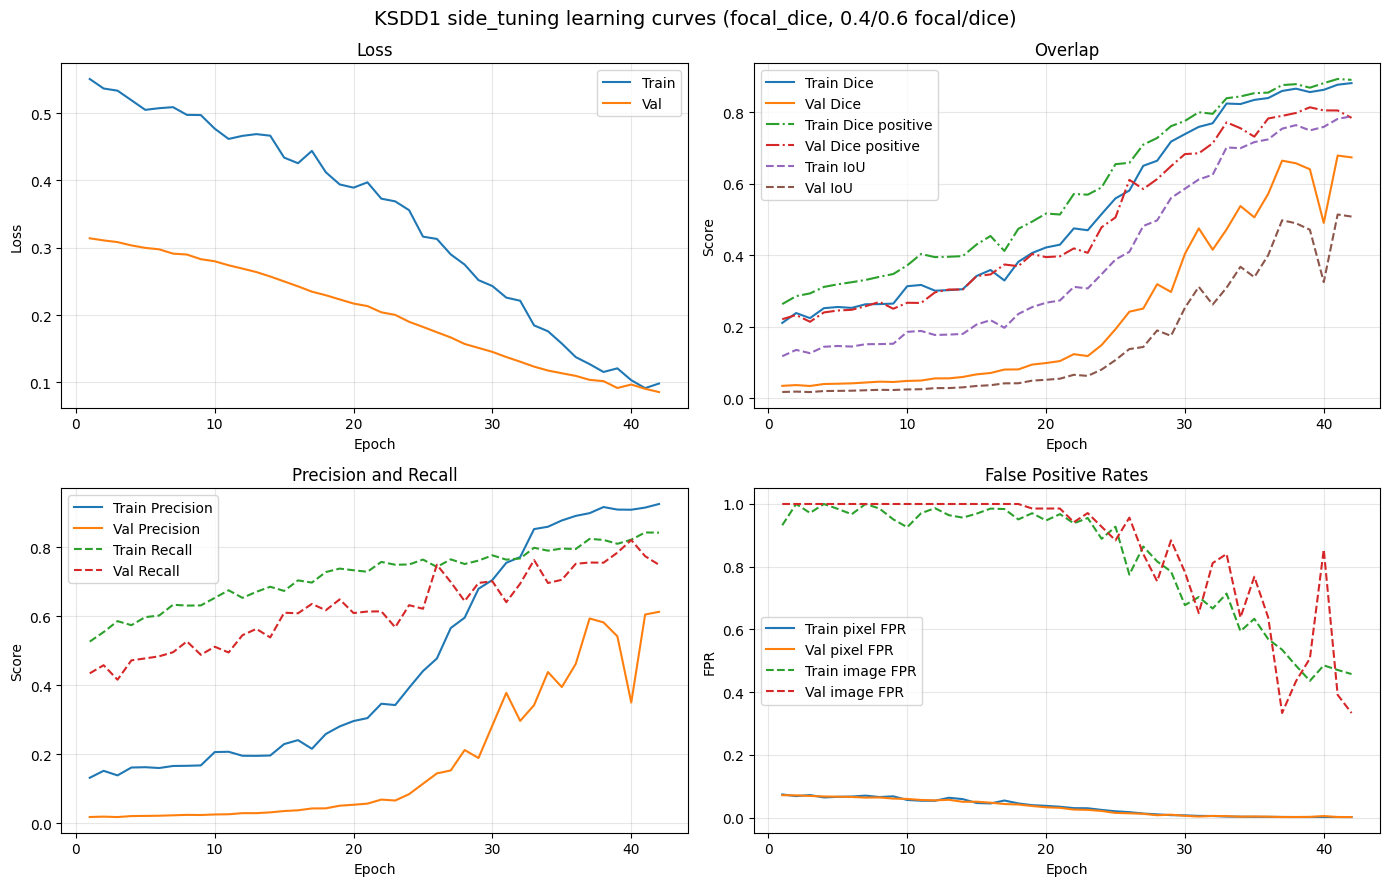

Saved: learning_curves_ksdd1.png



Threshold and min-area sweep:
thr=0.50 | min_area=  0 | score=0.2052 | dice=0.3648 | dice_pos=0.7131 | iou=0.2231 | precision=0.2355 | recall=0.8082 | pixel_fpr=0.007989 | image_fpr=1.0000
thr=0.60 | min_area=  0 | score=0.2223 | dice=0.3941 | dice_pos=0.7292 | iou=0.2454 | precision=0.2611 | recall=0.8034 | pixel_fpr=0.006925 | image_fpr=1.0000
thr=0.70 | min_area=  0 | score=0.2387 | dice=0.4254 | dice_pos=0.7447 | iou=0.2701 | precision=0.2900 | recall=0.7979 | pixel_fpr=0.005951 | image_fpr=1.0000
thr=0.75 | min_area=  0 | score=0.2465 | dice=0.4425 | dice_pos=0.7520 | iou=0.2841 | precision=0.3066 | recall=0.7946 | pixel_fpr=0.005473 | image_fpr=1.0000
thr=0.80 | min_area=  0 | score=0.2546 | dice=0.4617 | dice_pos=0.7595 | iou=0.3001 | precision=0.3260 | recall=0.7909 | pixel_fpr=0.004981 | image_fpr=1.0000
thr=0.85 | min_area=  0 | score=0.2631 | dice=0.4833 | dice_pos=0.7675 | iou=0.3187 | precision=0.3491 | recall=0.7853 | pixel_fpr=0.004460 | image_fpr=1.0000
thr=0.90 | min_

In [17]:
# 14. Main
if __name__ == "__main__":
    strategy = "side_tuning"  # "side_tuning" or "side_tuning_l4"

    history, result, model, val_loader = run_experiment(strategy_name=strategy)
    print_result(result)
    plot_history(history, strategy_name=strategy)

    checkpoint_path = result["checkpoint_path"]
    thresholds = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.97, 0.975, 0.98, 0.985, 0.99]
    threshold_results, best_thr = evaluate_thresholds(
        model,
        val_loader,
        checkpoint_path=checkpoint_path,
        thresholds=thresholds,
        min_areas=THRESHOLD_MIN_AREAS,
    )


Using local dataset cache: /content/KolektorSDD-boxes
Dataset root: /content/KolektorSDD-boxes
Split: old KolektorSDD stratified sample split
Train: 126 images (42 positive, 84 negative)
Test/val: 79 images (10 positive, 69 negative)
Showing 4 defective images from test split
Part3.jpg
Part5.jpg
Part3.jpg
Part5.jpg
Initialized base segmentation bias with prior=0.009250, bias=-4.6738
Initial side-branch mix alpha=0.2000


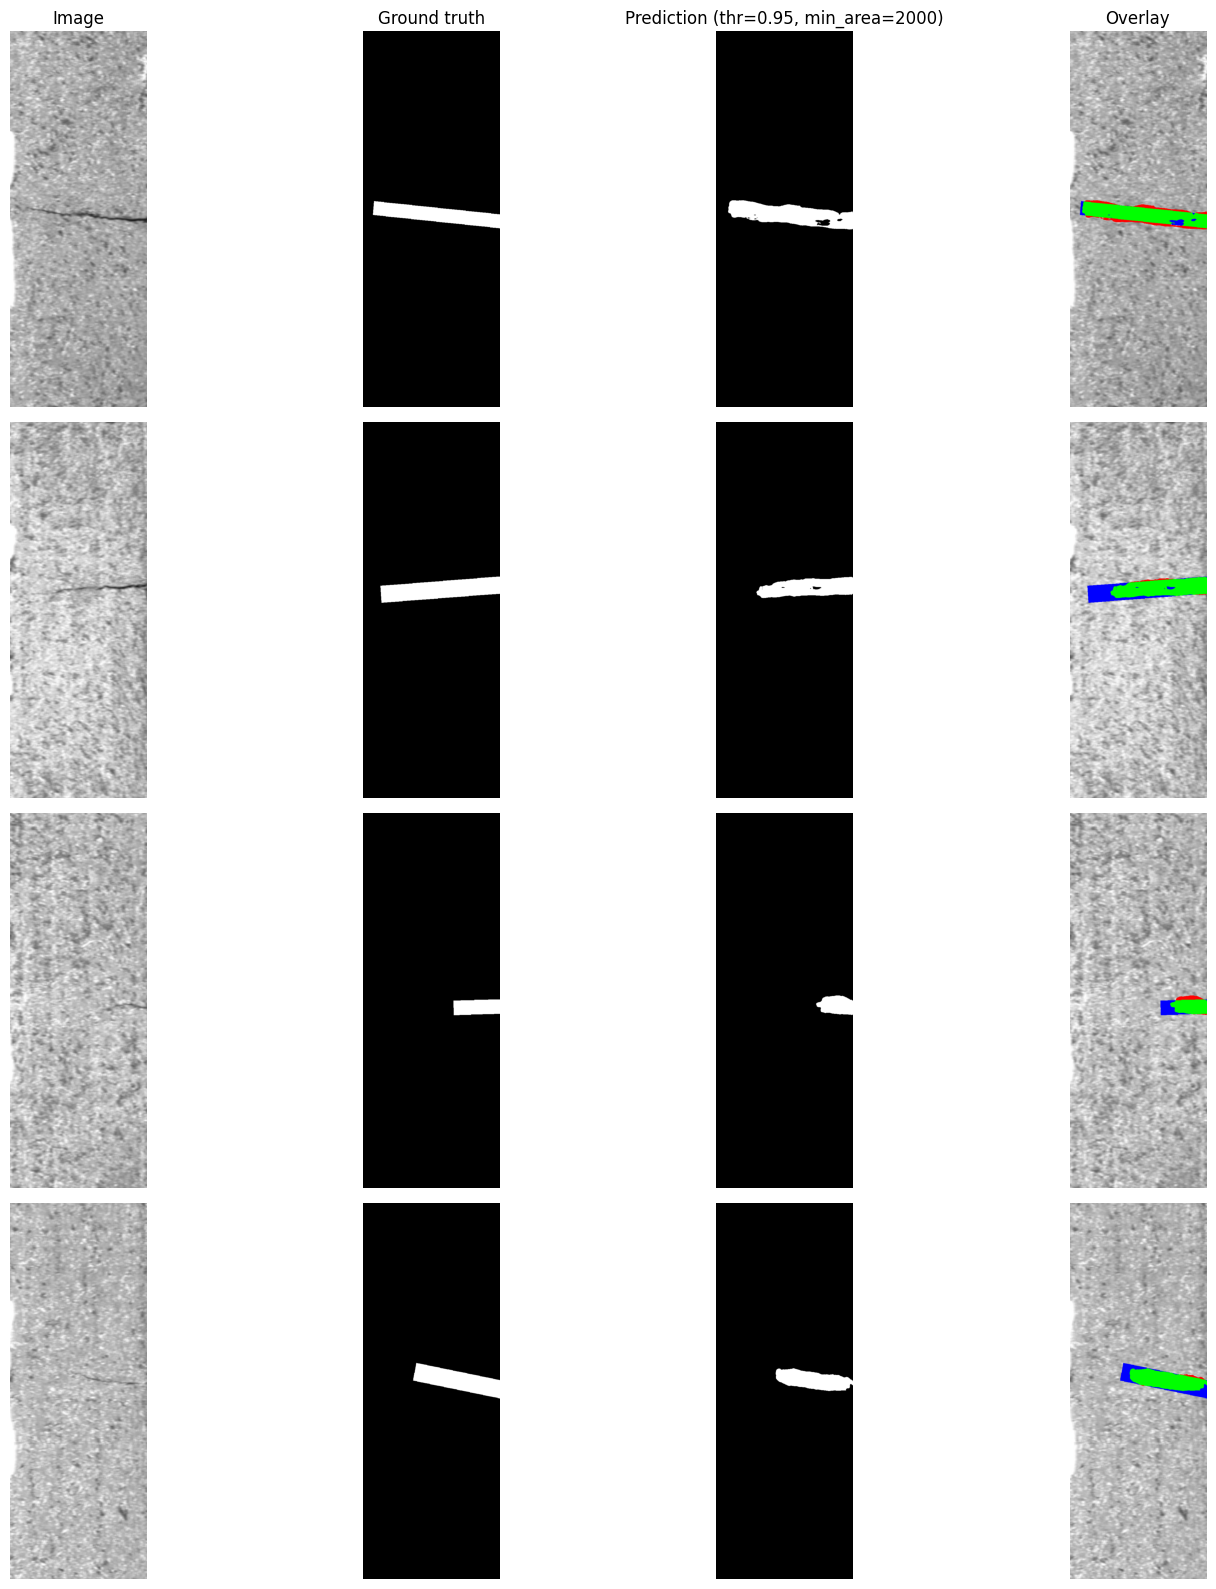

Saved: predictions_ksdd1.png


In [18]:
# 15. Positive-only qualitative results
def visualise_positive_predictions(checkpoint_path=None, split="test", n=4, thr=None, min_area=0, seed=SEED):
    if thr is None:
        thr = THR
    if checkpoint_path is None:
        checkpoint_path = result["checkpoint_path"] if "result" in globals() else "best_ksdd1_side_tuning.pth"

    data_root = prepare_data_root()
    train_samples, val_samples = load_official_split(data_root)
    samples = val_samples if split == "test" else train_samples
    positive_samples = [sample for sample in samples if sample["has_crack"]]
    if not positive_samples:
        raise RuntimeError(f"No defective images found in split={split!r}")

    rng = random.Random(seed)
    selected_samples = positive_samples.copy()
    rng.shuffle(selected_samples)
    selected_samples = selected_samples[:n]

    print(f"Showing {len(selected_samples)} defective images from {split} split")
    for sample in selected_samples:
        print(Path(sample["image"]).name)

    positive_loader = make_loader(
        CrackSegDataset(selected_samples, augment=False),
        batch_size=len(selected_samples),
        shuffle=False,
    )

    strategy_name = result["strategy"] if "result" in globals() else "side_tuning"
    if "result" in globals() and "foreground_prior" in result:
        foreground_prior = result["foreground_prior"]
    elif FOREGROUND_PRIOR is not None:
        foreground_prior = float(np.clip(FOREGROUND_PRIOR, *PRIOR_CLAMP))
    else:
        foreground_prior = estimate_foreground_prior(train_samples)

    positive_model = apply_strategy(
        build_model(foreground_prior, load_base_checkpoint=False),
        strategy_name=strategy_name,
    )
    visualise_predictions(
        positive_model,
        positive_loader,
        checkpoint_path=checkpoint_path,
        n=len(selected_samples),
        thr=thr,
        min_area=min_area,
    )


visualise_positive_predictions(
    checkpoint_path=result["checkpoint_path"],
    split="test",
    n=4,
    thr=best_thr["thr"] if "best_thr" in globals() else THR,
    min_area=best_thr.get("min_area", 0) if "best_thr" in globals() else 0,
)

## Export Results To Drive
Save the run artifacts to Google Drive under `results/<strategy>/` for comparison across notebooks.


In [19]:
import csv
import json
import shutil
from pathlib import Path


def _clean_csv_value(value):
    if hasattr(value, "item"):
        try:
            return value.item()
        except Exception:
            pass
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (list, tuple, dict)):
        return json.dumps(value)
    return value


def _write_csv(path, rows):
    rows = [dict(row) for row in rows] if rows else []
    fieldnames = []
    for row in rows:
        for key in row.keys():
            if key not in fieldnames:
                fieldnames.append(key)
    with open(path, "w", newline="", encoding="utf-8") as handle:
        if not fieldnames:
            return
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow({key: _clean_csv_value(row.get(key, "")) for key in fieldnames})


def _history_rows(history_dict):
    lengths = [len(value) for value in history_dict.values() if isinstance(value, list)]
    if not lengths:
        return []
    rows = []
    for idx in range(max(lengths)):
        row = {"epoch": idx + 1}
        for key, values in history_dict.items():
            if isinstance(values, list) and idx < len(values):
                row[key] = values[idx]
        rows.append(row)
    return rows


def _as_path(value):
    if value is None:
        return None
    text = str(value)
    if not text:
        return None
    return Path(text)


def _copy_first_existing(target_dir, target_name, candidates):
    for candidate in candidates:
        path = _as_path(candidate)
        if path is not None and path.is_file():
            destination = target_dir / target_name
            shutil.copy2(path, destination)
            return destination
    return None


def _threshold_rows_and_best():
    rows = globals().get("threshold_results")
    best = globals().get("best_thr")
    if rows is not None:
        return list(rows), best

    threshold_path = None
    if "result" in globals() and isinstance(result, dict):
        threshold_path = result.get("threshold_sweep_path")
    path = _as_path(threshold_path)
    if path is not None and path.is_file():
        with open(path, "r", encoding="utf-8") as handle:
            payload = json.load(handle)
        if isinstance(payload, dict):
            return list(payload.get("rows", [])), payload.get("best", best)
        if isinstance(payload, list):
            return payload, best
    return [], best


strategy_name = "unknown"
if "result" in globals() and isinstance(result, dict):
    strategy_name = str(result.get("strategy", strategy_name))
elif "strategy" in globals():
    strategy_name = str(strategy)

output_dir = Path(".")
if "cfg" in globals() and hasattr(cfg, "output_dir"):
    output_dir = Path(cfg.output_dir)
elif "OUTPUT_DIR" in globals():
    output_dir = Path(OUTPUT_DIR)

save_dir = Path("/content/drive/MyDrive/results") / strategy_name
save_dir.mkdir(parents=True, exist_ok=True)

history_rows = _history_rows(history if "history" in globals() else {})
_write_csv(save_dir / "epochs.csv", history_rows)

threshold_rows, threshold_best = _threshold_rows_and_best()
_write_csv(save_dir / "threshold_area_sweep.csv", threshold_rows)
if threshold_best is not None:
    _write_csv(save_dir / "best_threshold_area.csv", [threshold_best])

if "result" in globals() and isinstance(result, dict):
    with open(save_dir / "best_result.json", "w", encoding="utf-8") as handle:
        json.dump(result, handle, indent=2)
    _write_csv(save_dir / "best_result.csv", [result])

learning_curves_path = result.get("learning_curves_path") if "result" in globals() and isinstance(result, dict) else None
predictions_path = result.get("predictions_path") if "result" in globals() and isinstance(result, dict) else None

copied_files = []
for copied in [
    _copy_first_existing(
        save_dir,
        "learning_curves.png",
        [
            learning_curves_path,
            output_dir / f"learning_curves_ksdd1_{strategy_name}.png",
            Path(f"learning_curves_ksdd1_{strategy_name}.png"),
            Path("learning_curves_ksdd1.png"),
        ],
    ),
    _copy_first_existing(
        save_dir,
        "predictions.png",
        [
            predictions_path,
            output_dir / f"predictions_ksdd1_{strategy_name}.png",
            Path(f"predictions_ksdd1_{strategy_name}.png"),
        ],
    ),
    _copy_first_existing(
        save_dir,
        "positive_predictions.png",
        [
            output_dir / f"positive_predictions_ksdd1_{strategy_name}.png",
            Path(f"positive_predictions_ksdd1_{strategy_name}.png"),
            Path("positive_predictions_ksdd1.png"),
            Path("predictions_ksdd1.png"),
        ],
    ),
]:
    if copied is not None:
        copied_files.append(str(copied))

print(f"Saved results to: {save_dir}")
print("CSV files:")
for name in ["epochs.csv", "threshold_area_sweep.csv", "best_threshold_area.csv", "best_result.csv"]:
    path = save_dir / name
    if path.exists():
        print(path)
print("PNG files:")
for path in copied_files:
    print(path)


Saved results to: /content/drive/MyDrive/results/side_tuning
CSV files:
/content/drive/MyDrive/results/side_tuning/epochs.csv
/content/drive/MyDrive/results/side_tuning/threshold_area_sweep.csv
/content/drive/MyDrive/results/side_tuning/best_threshold_area.csv
/content/drive/MyDrive/results/side_tuning/best_result.csv
PNG files:
/content/drive/MyDrive/results/side_tuning/learning_curves.png
/content/drive/MyDrive/results/side_tuning/positive_predictions.png
